In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

# Import everything from your fc_model.py file
from fc_model import DynamicFCBaseline, load_flat_csv_data, train_and_tune

# Setup device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cpu


## Loading Data

In [3]:
# --- Define Paths ---
train_csv = "../../Data/Train_Test_Data/Not_Seperated/Clips_Split_80_20/Train_clips_augmented"
test_csv = "../../Data/Train_Test_Data/Not_Seperated/Clips_Split_80_20/Test_clips_augmented"

# --- Load Data ---
train_loader, test_loader, num_classes, label_encoder = load_flat_csv_data(
    train_csv, 
    test_csv, 
    batch_size=64
)

Gathering CSV files from folders...
Loaded 621152 training rows and 156336 testing rows.
✅ Ready! Found 14 classes.


## Training Model


In [6]:
# --- Configuration ---
epochs_to_run = 100
patience = 5

model = DynamicFCBaseline(
    input_size=84, 
    hidden_size=128, 
    num_layers=2, 
    num_classes=num_classes, 
    dropout=0.3
).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# --- Run Training with Early Stopping ---
print("Starting Training...")
train_hist, val_hist = train_and_tune(
    model, 
    train_loader, 
    test_loader, 
    criterion, 
    optimizer, 
    max_epochs=epochs_to_run, 
    device=device,
    patience=patience
)

Starting Training...
Epoch [1/100] - Train Loss: 0.8382 | Val Loss: 0.5976
Epoch [2/100] - Train Loss: 0.6152 | Val Loss: 0.5322
Epoch [3/100] - Train Loss: 0.5484 | Val Loss: 0.4692
Epoch [4/100] - Train Loss: 0.5113 | Val Loss: 0.4379
Epoch [5/100] - Train Loss: 0.4862 | Val Loss: 0.4477
No improvement for 1 epochs.
Epoch [6/100] - Train Loss: 0.4686 | Val Loss: 0.4297
Epoch [7/100] - Train Loss: 0.4552 | Val Loss: 0.4255
Epoch [8/100] - Train Loss: 0.4435 | Val Loss: 0.4080
Epoch [9/100] - Train Loss: 0.4354 | Val Loss: 0.3931
Epoch [10/100] - Train Loss: 0.4269 | Val Loss: 0.3846
Epoch [11/100] - Train Loss: 0.4190 | Val Loss: 0.3895
No improvement for 1 epochs.
Epoch [12/100] - Train Loss: 0.4123 | Val Loss: 0.3893
No improvement for 2 epochs.
Epoch [13/100] - Train Loss: 0.4093 | Val Loss: 0.4060
No improvement for 3 epochs.
Epoch [14/100] - Train Loss: 0.4041 | Val Loss: 0.3753
Epoch [15/100] - Train Loss: 0.3993 | Val Loss: 0.3863
No improvement for 1 epochs.
Epoch [16/100] - T

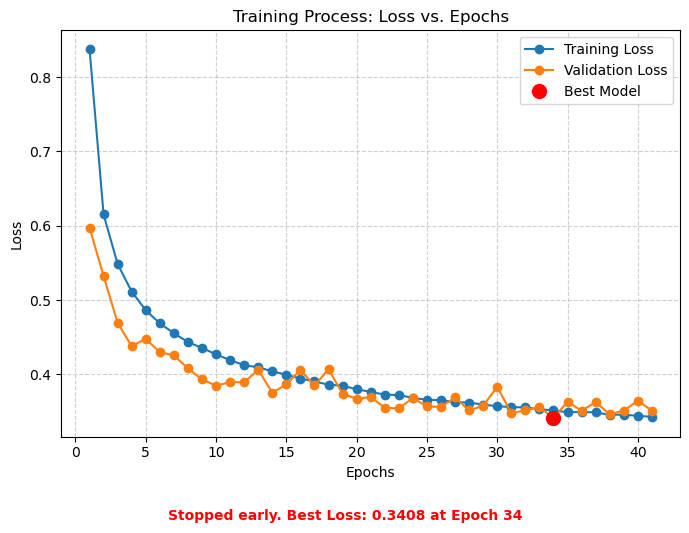

In [7]:
import matplotlib.pyplot as plt

# We use len(train_hist) because the loop might have stopped early
actual_epochs = range(1, len(train_hist) + 1)

plt.figure(figsize=(7, 5)) 
plt.plot(actual_epochs, train_hist, label='Training Loss', color='#1f77b4', marker='o')
plt.plot(actual_epochs, val_hist, label='Validation Loss', color='#ff7f0e', marker='o')

# Red dot logic
min_val_loss = min(val_hist)
min_epoch = val_hist.index(min_val_loss) + 1
plt.plot(min_epoch, min_val_loss, 'ro', markersize=10, label='Best Model')

plt.title('Training Process: Loss vs. Epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

plt.figtext(0.5, -0.05, f"Stopped early. Best Loss: {min_val_loss:.4f} at Epoch {min_epoch}", 
            ha='center', color='red', fontweight='bold')

plt.tight_layout()
plt.show()